<a href="https://colab.research.google.com/github/Ch-Ibrahim/JvqxoRA0CZZxKRuZ/blob/main/Project_1_Happy_Customers_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The client is a logistics and delivery startup focused on maximizing customer satisfaction. While collecting feedback is challenging, it remains the most reliable way to measure satisfaction and enhance operations. To support this goal, the company has shared a subset of a larger survey and requested the development of an effective machine learning approach to predict customer happiness based on survey responses.


**Goals**


The objective of this project is to develop a machine learning model capable of predicting customer happiness based on their responses to survey questions.

**Success Metrics**

The target performance benchmark is achieving an accuracy score of at least ***73%.*** Alternatively, a solution may be considered successful if it demonstrates clear methodological advantages or provides valuable insights beyond raw accuracy. All approaches and findings that contribute to understanding customer satisfaction are of interest.


Step1: Import Library


In [32]:
# basics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# models: Models that I will test to choose the best Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# accuracy metrics
from sklearn import metrics
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, classification_report, roc_curve, precision_score, recall_score, roc_auc_score

# **Load & Read Dataset**

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
path="/content/drive/MyDrive/Colab Notebooks/Datasets/ACME-HappinessSurvey2020.csv"
data=pd.read_csv(path)
pd.set_option('display.max_columns',None)
data.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


# **Data Description:**

**Y** = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers

**X1** = my order was delivered on time

**X2** = contents of my order was as I expected

**X3** = I ordered everything I wanted to order

**X4** = I paid a good price for my order

**X5** = I am satisfied with my courier

**X6** = the app makes ordering easy for me




Attributes X1 to **X6** indicate the responses for each question and have values from 1 to 5 where the smaller number indicates less and the higher number indicates more towards the answer.

# **Data Visualization**

It often makes things much easier to understand when visualizations and graphics are used. The same goes for Machine Learning problems. Different aspects of the dataset are visualized to get a better understanding of the data,


Produce a count pie for the **target attribute** to gain insights into its distribution within the dataset.

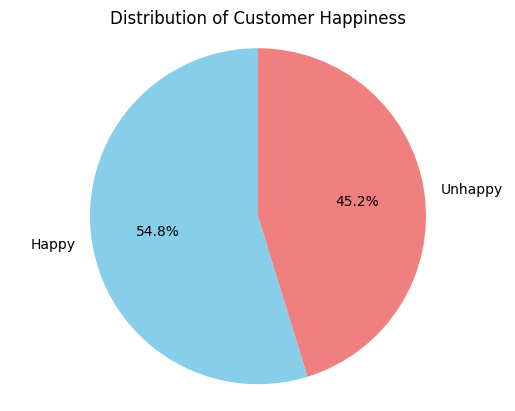

In [35]:
y_counts = data['Y'].value_counts()
labels = ['Happy', 'Unhappy']


plt.pie(y_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Customer Happiness')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

The plot indicates that the number of happy customers exceeded the number of unhappy ones, although the margin between the two groups is relatively small.


# **Model Building and Training**

In supervised learning, it is essential to divide the dataset into training and testing subsets. The training data is used to fit the model and help the algorithm learn the relationship between features and the target variable, while the test data is reserved for evaluating how well the model performs. In the code, the dataset is first separated into features and target, and then split into training and test sets.

In [36]:
Y=data['Y']
X=data[['X1','X2','X3','X4','X5','X6']]

Y_train, Y_test, X_train, X_test = train_test_split(Y, X, test_size=0.15, random_state=54321)

# **Fitting and Evaluating the Models**

We train several machine learning models and use Recall and AUC to decide which one works best. Recall is important because, in past fintech projects, low recall meant we missed many risky applicants, leading to financial losses. So, we want to reduce the number of such cases. AUC is also useful since it measures the overall strength of a model by checking its performance across different thresholds


Let’s define the list of models to train:

In [37]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier # Assuming xgboost is installed, if not, it will need to be installed.

clf = [

    RandomForestClassifier(),
    #linear_model.Perceptron(),
    GaussianNB(),
    CalibratedClassifierCV(LinearSVC()), # SVC does not have predict_proba, and is wrapped into CalibratedClassifierCV
    DecisionTreeClassifier(),
    XGBClassifier(),
    LogisticRegression(),
    KNeighborsClassifier()
    ]

In [38]:
clf_columns = []
clf_compare = pd.DataFrame(columns = clf_columns)

row_index = 0
for alg in clf:

    predicted = alg.fit(X_train, Y_train).predict(X_test)
    fp, tp, th = roc_curve(Y_test, predicted)
    clf_name = alg.__class__.__name__
    clf_compare.loc[row_index,'Classifier'] = clf_name
    clf_compare.loc[row_index, 'Train Accuracy'] = round(alg.score(X_train, Y_train), 4)
    clf_compare.loc[row_index, 'Test Accuracy'] = round(alg.score(X_test, Y_test), 4)
    clf_compare.loc[row_index, 'Precission'] = precision_score(Y_test, predicted)
    clf_compare.loc[row_index, 'Recall'] = recall_score(Y_test, predicted)
    clf_compare.loc[row_index, 'AUC'] = round(roc_auc_score(Y_test, alg.predict_proba(X_test)[:,1]),5)

    row_index+=1

clf_compare.sort_values(by = ['AUC'], ascending = False, inplace = True)
clf_compare

,Classifier,Train Accuracy,Test Accuracy,Precission,Recall,AUC
1,GaussianNB,0.6075,0.5789,0.615385,0.727273,0.71591
5,LogisticRegression,0.5607,0.5789,0.615385,0.727273,0.71591
4,XGBClassifier,0.9252,0.6842,0.727273,0.727273,0.69318
2,CalibratedClassifierCV,0.5514,0.6842,0.647059,1.000000,0.63636
6,KNeighborsClassifier,0.7009,0.6316,0.642857,0.818182,0.61932
0,RandomForestClassifier,0.9439,0.5263,0.583333,0.636364,0.61364
3,DecisionTreeClassifier,0.9439,0.5263,0.583333,0.636364,0.48295


This result above is the evaluation of multiple machine learning classification models. It iterates through each classifier in the clf list, which I defined earlier.



For each classifier, the code performs the following actions:



**Trains the model:**  alg.fit(X_train, Y_train) trains the current classifier using your training features (X_train) and training target variable (Y_train).





**Makes predictions:** alg.predict(X_test) generates predictions on the unseen test features (X_test).


Calculates performance metrics: It computes and stores several evaluation metrics


*   Classifier name: alg.__class__.__name__ gets the name of the current model.

*   Train Accuracy: alg.score(X_train, Y_train) measures how well the model performed on the data it was trained on.



*   Test Accuracy: alg.score(X_test, Y_test) measures the model's performance on the unseen test data.


*   Precision: precision_score(Y_test, predicted) indicates the proportion of positive identifications that were actually correct.



*   Recall: recall_score(Y_test, predicted) indicates the proportion of actual positives that were correctly identified.


*   AUC (Area Under the Receiver Operating Characteristic Curve): roc_auc_score(Y_test, alg.predict_proba(X_test)[:,1]) measures the overall performance of the classifier across all possible classification thresholds.



**Stores results:** All these metrics are added as a new row to the clf_compare DataFrame.









# **Feature Selection**

Feature selection is the process of choosing only the most useful input features for a machine learning models. It helps improve model performance.




In [39]:
# define feature selection
correlations = data.corr()
features_to_remove = correlations.loc[:, correlations.loc['Y'] < 0.15].columns
data_sel = data.drop(features_to_remove, axis=1)

X_sel = data_sel.drop('Y', axis=1)
y = data_sel['Y']

X_selected_train, X_selected_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.15, random_state=12345)


features_to_remove

data_sel.shape
data_sel.columns

Index(['Y', 'X1', 'X3', 'X5', 'X6'], dtype='object')

In [40]:
clf_columns = []
clf_compare = pd.DataFrame(columns = clf_columns)

row_index = 0
for alg in clf:

    predicted1 = alg.fit(X_selected_train, y_train).predict(X_selected_test)
    fp, tp, th = roc_curve(y_test, predicted1)
    clf_name = alg.__class__.__name__
    clf_compare.loc[row_index,'Classifier1'] = clf_name
    clf_compare.loc[row_index, 'Train Accuracy1'] = round(alg.score(X_selected_train, y_train), 4)
    clf_compare.loc[row_index, 'Test Accuracy1'] = round(alg.score(X_selected_test, y_test), 4)
    clf_compare.loc[row_index, 'Precission1'] = precision_score(y_test, predicted1)
    clf_compare.loc[row_index, 'Recall1'] = recall_score(y_test, predicted1)
    clf_compare.loc[row_index, 'AUC1'] = round(roc_auc_score(y_test, alg.predict_proba(X_selected_test)[:,1]),5)

    row_index+=1

clf_compare.sort_values(by = ['AUC1'], ascending = False, inplace = True)
clf_compare

,Classifier1,Train Accuracy1,Test Accuracy1,Precission1,Recall1,AUC1
4,XGBClassifier,0.8131,0.7368,0.692308,0.9,0.83333
0,RandomForestClassifier,0.8318,0.7895,0.714286,1.0,0.82222
6,KNeighborsClassifier,0.7383,0.8421,0.818182,0.9,0.79444
3,DecisionTreeClassifier,0.8318,0.7368,0.692308,0.9,0.70000
2,CalibratedClassifierCV,0.5794,0.5263,0.538462,0.7,0.65556
5,LogisticRegression,0.6075,0.5263,0.538462,0.7,0.65556
1,GaussianNB,0.5888,0.5263,0.538462,0.7,0.64444


# **Conclusions**

Based on the clf_compare results, here are the models that have a Test Accuracy greater than 0.73:



*   RandomForestClassifier

*   KNeighborsClassifier


*   XGBClassifier

*   DecisionTreeClassifier








Among these, the XGBClassifier has the highest AUC1 of 0.83333, while also meeting the accuracy requirement of greater than 0.73. Therefore, the XGBClassifier is the best model based on these criteria.